# 01 — Metric Spaces

This notebook begins the computational study of **Topological Data Analysis (TDA)** with the basic structure on which much of TDA is built: a **metric space**.

The guiding principle of this repository is:

> **Learn the mathematics by doing it.** (attributed to Paul Erdos.)

We will introduce the definitions in mathematical language and then make them concrete through small computational experiments.

### Learning goals

By the end of this notebook, you should be able to:

- define a set, a distance function, and a metric space;
- check the four metric axioms computationally;
- work with Euclidean and Manhattan metrics;
- understand finite metric spaces through their distance matrices;
- construct open balls;
- see how a metric turns a collection of points into a geometric object;
- distinguish a genuine metric from a function that is **not** a metric;
- understand why metric spaces are natural starting points for point-cloud data.

We will **not** use Ripser, Persim, or GUDHI yet. Those tools will appear later, after the underlying mathematical objects have been introduced.


## 1. Sets and points

A **set** is a collection of objects. We will usually write a set as

$$
X = \{x_1,x_2,\ldots,x_n\}.
$$

The elements of \(X\) are called **points**.

In TDA, the points may represent:

- samples from a geometric object;
- observations in a data set;
- pixels or voxels;
- molecular configurations;
- states of a physical system.

For example,

$$
X = \{(0,0),(1,0),(0,1),(1,1)\}
$$

is a finite set of four points in the plane.

A set by itself has no notion of distance. To talk about points being *close* or *far apart*, we need additional structure.

### Example

$$
X = \{0,1,2,3\}
$$

is a set of four points.


## 2. Distance function

A **distance function** on a set $X$ is a function

$$
d : X\times X \longrightarrow \mathbb{R}.
$$

For two points $x,y\in X$, the number $d(x,y)$ is intended to measure how far apart $x$ and $y$ are.

Not every function $X \times X \to \mathbb R\$ is a valid distance.

To be a **metric**, the function must satisfy four axioms.


## 3. Metric

Let $X$ be a set. A function

$$
d:X\times X\to\mathbb{R}
$$

is a **metric** if, for all $x,y,z\in X$,

### (M1) Non-negativity

$$
d(x,y)\geq 0.
$$

### (M2) Identity of indiscernibles

$$
d(x,y)=0
\quad \Longleftrightarrow \quad
x=y.
$$

### (M3) Symmetry

$$
d(x,y)=d(y,x).
$$

### (M4) Triangle inequality

$$
d(x,z)\leq d(x,y)+d(y,z).
$$

A pair $(X,d)$ consisting of a set $X$ and a metric $d$ is called a **metric space**.

### Example

The real numbers with

$$
d(x,y)=|x-y|
$$

form a metric space:

$$
(\mathbb R,|\cdot-\cdot|).
$$

### Non-example

The function

$$
d(x,y)=(x-y)^2
$$

is nonnegative and symmetric, and vanishes exactly when \(x=y\), but it does **not** satisfy the triangle inequality.

For example,

$$
d(0,2)=4
$$

while

$$
d(0,1)+d(1,2)=1+1=2.
$$

Thus \(4\not\leq 2\), so this function is not a metric.


## 4. A first computational experiment: checking metric axioms

For a finite set, we can test the metric axioms by checking every relevant pair or triple of points.

### Pseudocode

```text
INPUT:
    a finite set X
    a candidate distance function d

CHECK:
    for every x, y in X:
        verify d(x, y) >= 0
        verify d(x, y) = 0 exactly when x = y
        verify d(x, y) = d(y, x)

    for every x, y, z in X:
        verify d(x, z) <= d(x, y) + d(y, z)

OUTPUT:
    whether d satisfies all four metric axioms
```

We will implement this literally.


In [1]:
from itertools import product

def check_metric(points, distance, tol=1e-12):
    """Check the four metric axioms on a finite set of points."""
    points = list(points)

    nonnegative = True
    identity = True
    symmetric = True
    triangle = True

    for x, y in product(points, repeat=2):
        dxy = distance(x, y)

        if dxy < -tol:
            nonnegative = False

        if (abs(dxy) <= tol) != (x == y):
            identity = False

        if abs(dxy - distance(y, x)) > tol:
            symmetric = False

    for x, y, z in product(points, repeat=3):
        if distance(x, z) > distance(x, y) + distance(y, z) + tol:
            triangle = False

    return {
        "non-negativity": nonnegative,
        "identity of indiscernibles": identity,
        "symmetry": symmetric,
        "triangle inequality": triangle,
    }


## 5. The metric on the real line

The standard metric on \(\mathbb R\) is

\[
d(x,y)=|x-y|.
\]

### Pseudocode

```text
INPUT:
    two real numbers x and y

COMPUTE:
    distance = absolute value of (x - y)

RETURN:
    distance
```


In [2]:
def real_distance(x, y):
    return abs(x - y)

X = [0, 1, 2, 3]

check_metric(X, real_distance)


{'non-negativity': True,
 'identity of indiscernibles': True,
 'symmetry': True,
 'triangle inequality': True}

The output should show `True` for all four axioms.

This is our first example of a metric space:

$$
(X,d) = (\{0,1,2,3\}, |\cdot-\cdot|).
$$

The same formula also defines a metric on all of \(\mathbb R\).


## 6. Euclidean distance

For points in $\mathbb R^n$, the standard Euclidean metric is

$$
d_2(x,y)
=
\sqrt{\sum_{i=1}^{n}(x_i-y_i)^2}.
$$

For \(x=(x_1,\ldots,x_n)\) and \(y=(y_1,\ldots,y_n)\), this is the familiar straight-line distance.

For example,

$$
d_2((0,0),(3,4))=5.
$$

### Pseudocode

```text
INPUT:
    two vectors x and y of the same dimension

INITIALIZE:
    total = 0

FOR each coordinate i:
    difference = x[i] - y[i]
    total = total + difference^2

RETURN:
    square root of total
```


In [3]:
import numpy as np

def euclidean_distance(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    return np.linalg.norm(x - y)

points_2d = [
    (0, 0),
    (1, 0),
    (0, 1),
    (1, 1),
]

check_metric(points_2d, euclidean_distance)


{'non-negativity': True,
 'identity of indiscernibles': True,
 'symmetry': True,
 'triangle inequality': True}

In [4]:
x = np.array([0, 0])
y = np.array([3, 4])

euclidean_distance(x, y)


np.float64(5.0)

## 7. Manhattan distance

Another important metric on $\mathbb R^n$ is the **Manhattan metric**, also called **NewYork Metric**, or the \(L^1\) metric:

$$
d_1(x,y)
=
\sum_{i=1}^{n}|x_i-y_i|.
$$

In $\mathbb R^2$, this measures distance along a rectangular grid.

For

$$
x=(0,0),\qquad y=(3,4),
$$

we have

$$
d_1(x,y)=|3|+|4|=7.
$$

### Pseudocode

```text
INPUT:
    two vectors x and y

INITIALIZE:
    total = 0

FOR each coordinate i:
    total = total + absolute_value(x[i] - y[i])

RETURN:
    total
```


In [5]:
def manhattan_distance(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    return np.sum(np.abs(x - y))

check_metric(points_2d, manhattan_distance)


{'non-negativity': True,
 'identity of indiscernibles': True,
 'symmetry': True,
 'triangle inequality': True}

In [6]:
manhattan_distance(np.array([0, 0]), np.array([3, 4]))


np.int64(7)

### Same points, different geometry

The same set of points can carry different metrics.

For example,

$$
d_2((0,0),(1,1))=\sqrt 2,
$$

whereas

$$
d_1((0,0),(1,1))=2.
$$

This distinction will become important later: **TDA depends not only on the points, but also on the metric used to measure their relationships.**


In [7]:
x = np.array([0, 0])
y = np.array([1, 1])

print("Euclidean distance:", euclidean_distance(x, y))
print("Manhattan distance:", manhattan_distance(x, y))


Euclidean distance: 1.4142135623730951
Manhattan distance: 2


## 8. Distance matrices

For a finite metric space

$$
X=\{x_1,\ldots,x_n\},
$$

we can record all pairwise distances in a matrix:

$$
D=
\begin{pmatrix}
d(x_1,x_1) & d(x_1,x_2) & \cdots & d(x_1,x_n)\\
d(x_2,x_1) & d(x_2,x_2) & \cdots & d(x_2,x_n)\\
\vdots & \vdots & \ddots & \vdots\\
d(x_n,x_1) & d(x_n,x_2) & \cdots & d(x_n,x_n)
\end{pmatrix}.
$$

For a metric, this matrix has:

- zeros on the diagonal;
- nonnegative entries;
- symmetry across the diagonal.

### Pseudocode

```text
INPUT:
    points X = [x1, ..., xn]
    metric d

CREATE:
    an n by n matrix D

FOR i from 1 to n:
    FOR j from 1 to n:
        D[i,j] = d(xi, xj)

RETURN:
    D
```


In [8]:
def distance_matrix(points, distance):
    points = list(points)
    n = len(points)
    D = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            D[i, j] = distance(points[i], points[j])

    return D

D_euclidean = distance_matrix(points_2d, euclidean_distance)
D_euclidean


array([[0.        , 1.        , 1.        , 1.41421356],
       [1.        , 0.        , 1.41421356, 1.        ],
       [1.        , 1.41421356, 0.        , 1.        ],
       [1.41421356, 1.        , 1.        , 0.        ]])

In [9]:
D_manhattan = distance_matrix(points_2d, manhattan_distance)
D_manhattan


array([[0., 1., 1., 2.],
       [1., 0., 2., 1.],
       [1., 2., 0., 1.],
       [2., 1., 1., 0.]])

Compare the two matrices.

The diagonal is zero in both cases, and both matrices are symmetric. But the off-diagonal values differ because the metrics encode different notions of distance.

This is one of the first computational lessons of TDA:

> **A data set does not determine its geometry until we specify how distances are measured.**


## 9. Open balls

Let $(X,d)$ be a metric space, let $x\in X$, and let $r>0$.

The **open ball of radius $r$ centered at $x$** is

$$
B_r(x)
=
\{y\in X:d(x,y)<r\}.
$$

For example, in $\mathbb R$,

$$
B_2(1)=\{y\in\mathbb R:|y-1|<2\}=(-1,3).
$$

For a finite metric space, the open ball is simply a subset of the finite set.

### Pseudocode

```text
INPUT:
    finite metric space X
    center x
    radius r

INITIALIZE:
    ball = empty set

FOR every point y in X:
    IF d(x, y) < r:
        add y to ball

RETURN:
    ball
```


In [10]:
def open_ball(points, center, radius, distance):
    return [
        point for point in points
        if distance(center, point) < radius
    ]

X = points_2d

print("Center:", (0, 0))
print("Radius:", 1.1)
print("Open ball:",

open_ball(X, (0, 0), 1.1, euclidean_distance))

Center: (0, 0)
Radius: 1.1
Open ball: [(0, 0), (1, 0), (0, 1)]


## 10. Visualizing metric balls in the plane

For Euclidean distance, an open ball in $\mathbb R^2$ is circular. For Manhattan distance, it is diamond-shaped.

### Pseudocode

```text
CREATE:
    a grid of points in the plane

FOR each grid point:
    compute its distance from the chosen center

MARK:
    points whose distance is less than r

PLOT:
    the selected points

REPEAT:
    once with Euclidean distance
    once with Manhattan distance
```


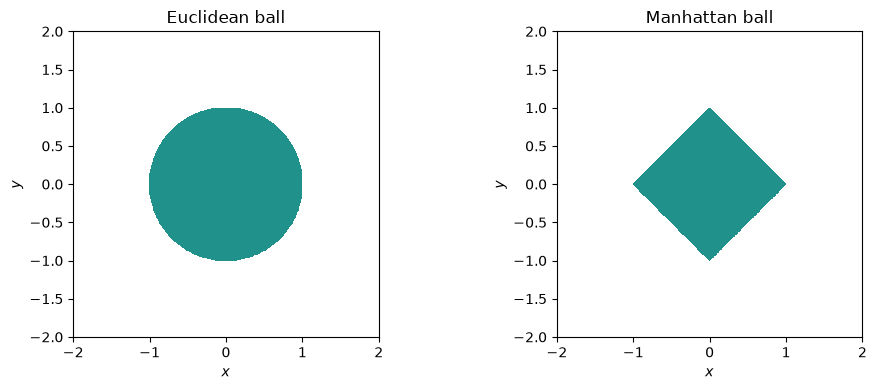

In [11]:
import matplotlib.pyplot as plt

grid = np.linspace(-2, 2, 401)
xx, yy = np.meshgrid(grid, grid)

radius = 1.0

euclidean_values = np.sqrt(xx**2 + yy**2)
manhattan_values = np.abs(xx) + np.abs(yy)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].contourf(
    xx, yy, euclidean_values < radius,
    levels=[0.5, 1.5]
)
axes[0].set_title("Euclidean ball")
axes[0].set_aspect("equal")

axes[1].contourf(
    xx, yy, manhattan_values < radius,
    levels=[0.5, 1.5]
)
axes[1].set_title("Manhattan ball")
axes[1].set_aspect("equal")

for ax in axes:
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

plt.tight_layout()
plt.show()


Notice the contrast:

- Euclidean balls are circular.
- Manhattan balls are diamond-shaped.

The underlying set $\mathbb R^2$ is the same. What changed was the metric. This is why, in data analysis, the choice of metric can influence the topological information we recover.

## 11. A function that is not a metric

Consider

$$
d(x,y)=(x-y)^2.
$$

It fails the triangle inequality. Let's let the code find a counterexample.

### Pseudocode

```text
INPUT:
    a finite set X
    the candidate function d

FOR every triple (x, y, z):
    compute left = d(x, z)
    compute right = d(x, y) + d(y, z)

    IF left > right:
        report (x, y, z)
        report the failed inequality
        STOP
```


In [12]:
def squared_difference(x, y):
    return (x - y) ** 2

def find_triangle_counterexample(points, distance):
    for x, y, z in product(points, repeat=3):
        left = distance(x, z)
        right = distance(x, y) + distance(y, z)

        if left > right + 1e-12:
            return x, y, z, left, right

    return None

find_triangle_counterexample(
    [0, 1, 2, 3],
    squared_difference
)


(0, 1, 2, 4, 2)

The returned tuple gives a concrete witness to the failure of the triangle inequality.

A useful computational habit is:

> When a mathematical statement is false, try to make the computer find a small counterexample.


## 12. A subtle non-example: cosine similarity

A common quantity in data science is **cosine similarity**:

$$
\operatorname{cos}(x,y)
=
\frac{\langle x,y\rangle}
{\|x\|\|y\|}.
$$

It measures the angle between vectors, but it is **not itself a metric**.

One might try to turn it into a distance using

$$
1-\operatorname{cos}(x,y),
$$

but this function does not satisfy the triangle inequality in general. (Although, there is a way using the *Inner Product Space.*)

The lesson is important:

> A quantity that measures "difference" or "similarity" is not automatically a metric.

TDA requires us to pay attention to the mathematical properties of the chosen notion of distance.


## 13. Finite metric spaces from graphs

A graph gives another natural source of metrics.

Suppose a connected graph has edges of length $1$. Define

$$
d(u,v)
=
\text{length of the shortest path from }u\text{ to }v.
$$

This is the **shortest-path metric**.

For example, consider

```text
A --- B --- C
      |
      D
```

Then

$$
d(A,C)=2,\qquad d(A,D)=2,\qquad d(C,D)=2.
$$

### Pseudocode

```text
CREATE:
    a connected graph G

FOR each pair of vertices u, v:
    find a shortest path from u to v
    set d(u, v) equal to the number of edges in that path

RETURN:
    the resulting distance matrix
```

We can construct a small example with NetworkX.


In [13]:
import networkx as nx

G = nx.Graph()

G.add_edges_from([
    ("A", "B"),
    ("B", "C"),
    ("B", "D"),
])

graph_distance = dict(nx.all_pairs_shortest_path_length(G))
nodes = list(G.nodes)

D_graph = np.array([
    [graph_distance[u][v] for v in nodes]
    for u in nodes
])

print("Nodes:", nodes)
print("Distance matrix:")
print(D_graph)

print("\nMetric check:")
print(check_metric(nodes, lambda u, v: graph_distance[u][v]))


Nodes: ['A', 'B', 'C', 'D']
Distance matrix:
[[0 1 2 2]
 [1 0 1 1]
 [2 1 0 2]
 [2 1 2 0]]

Metric check:
{'non-negativity': True, 'identity of indiscernibles': True, 'symmetry': True, 'triangle inequality': True}


The graph gives us a metric space even though the points do not live naturally in Euclidean space.

This is an important theme for TDA:

$$
\boxed{\text{data} + \text{distance} \longrightarrow \text{metric space}}
$$

The points may come from geometry, a graph, a physical system, an image, or some other source. Once we have a meaningful metric, many TDA constructions become available.


## 14. Point clouds

A **point cloud** is a finite collection of points sampled from some space, often represented as

$$
X=\{x_1,\ldots,x_n\}\subseteq\mathbb R^d.
$$

For example, we can sample points from a circle.

The sampled points themselves do not explicitly tell us that the underlying object is a circle. We only see a finite collection of points.

TDA asks questions such as:

- Is there evidence of a connected component?
- Is there a loop?
- Are there higher-dimensional features?
- Which features persist across scales?

The first step is to understand the metric structure of the point cloud.

### Pseudocode

```text
CHOOSE:
    number of points n

FOR i = 1, ..., n:
    choose an angle theta_i
    set x_i = (cos(theta_i), sin(theta_i))

STORE:
    X = [x_1, ..., x_n]

COMPUTE:
    pairwise distances between points

PLOT:
    the point cloud
```


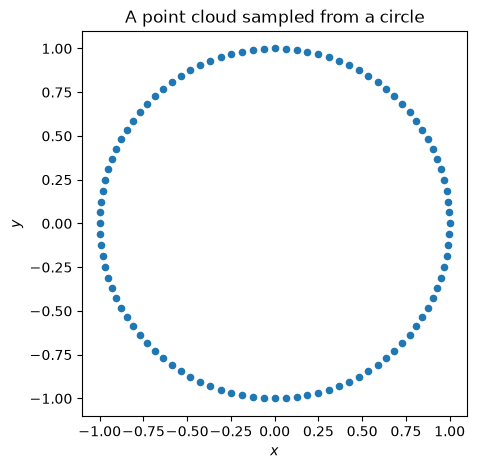

In [14]:
n = 100

theta = np.linspace(0, 2 * np.pi, n, endpoint=False)

circle_points = np.column_stack([
    np.cos(theta),
    np.sin(theta)
])

plt.figure(figsize=(5, 5))
plt.scatter(circle_points[:, 0], circle_points[:, 1], s=20)
plt.gca().set_aspect("equal")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("A point cloud sampled from a circle")
plt.show()


In [15]:
D_circle = distance_matrix(
    circle_points,
    euclidean_distance
)

print("Number of points:", len(circle_points))
print("Distance matrix shape:", D_circle.shape)
print("Distance between first two points:", D_circle[0, 1])


Number of points: 100
Distance matrix shape: (100, 100)
Distance between first two points: 0.06282151815625658


We have now reached the basic computational object that will drive much of the next part of the repository:

$$
\boxed{X=\{x_1,\ldots,x_n\}\quad\text{with a metric }d.}
$$

A point cloud together with pairwise distances gives us enough information to begin constructing simplicial complexes at different scales.

That is where **Vietoris–Rips complexes** and **persistent homology** will enter.


## 15. Summary

### Definitions

A **metric** is a function

$$
d:X\times X\to\mathbb R
$$

satisfying:

$$
d(x,y)\ge 0,
$$

$$
d(x,y)=0\iff x=y,
$$

$$
d(x,y)=d(y,x),
$$

and

$$
d(x,z)\le d(x,y)+d(y,z).
$$

A **metric space** is a pair

$$
(X,d).
$$

An **open ball** is

$$
B_r(x)=\{y\in X:d(x,y)<r\}.
$$

A **point cloud** is a finite collection of points, often equipped with a metric.

### Metrics encountered

- Euclidean metric:
  $$
  d_2(x,y)=\sqrt{\sum_i(x_i-y_i)^2}
  $$

- Manhattan metric:
  $$
  d_1(x,y)=\sum_i|x_i-y_i|
  $$

- Graph shortest-path metric:
  $$
  d(u,v)=\text{length of a shortest path from }u\text{ to }v.
  $$

### Main computational lesson

Different metrics can give different geometries to the same set of points.

That observation is fundamental for TDA.


## Exercises

### Exercise 1 — Metric axioms

Define

$$
d(x,y)=|x-y|
$$

on the finite set

$$
X=\{-2,-1,0,1,2\}.
$$

Use `check_metric` to verify all four axioms.

Then modify the function to

$$
d(x,y)=|x-y|^2
$$

and use the counterexample function to find a failure of the triangle inequality.

### Exercise 2 — Balls

For the four points

$$
(0,0),\ (1,0),\ (0,1),\ (1,1),
$$

compute the open ball centered at $(0,0)$ for several radii using both the Euclidean and Manhattan metrics.

What changes when the radius passes through

$$
1,\quad \sqrt 2,\quad 2?
$$

### Exercise 3 — Another metric

Find another metric on $\mathbb R^2$ that is different from both Euclidean and Manhattan distance.

Implement it and use `check_metric` on a finite collection of points.

### Exercise 4 — Another non-example

Find a function $f(x,y)$ that is:

- nonnegative;
- symmetric;
- zero exactly when $x=y$;

but is **not** a metric.

Use a computational search to find a counterexample to the triangle inequality.

### Exercise 5 — Point cloud

Generate a point cloud sampled from a figure-eight curve

$$
\gamma(t)=(\sin t,\sin(2t)).
$$

Plot it and compute its Euclidean distance matrix.

Before looking at any persistent homology, make a mathematical prediction:

> At a suitable scale, what topological features might we expect this point cloud to reveal?

We will return to this question later.


## References

1. S. Kumaresan, *Topology of Metric Spaces*, Narosa Publishing House.

2. D. Burago, Y. Burago, and S. Ivanov, *A Course in Metric Geometry*, Graduate Studies in Mathematics, Vol. 33, American Mathematical Society, 2001.

3. F. Chazal and B. Michel, *An Introduction to Topological Data Analysis: Fundamental and Practical Aspects for Data Scientists*, Frontiers in Artificial Intelligence 4 (2021), 667963.
   https://doi.org/10.3389/frai.2021.667963